In [122]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [123]:
df= pd.read_csv("smartcart_customers.csv")

In [124]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [125]:
df.shape

(2240, 22)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [127]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Handling missing values

In [128]:
df ["Income"] = df["Income"].fillna(df["Income"].median())

In [129]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [130]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [131]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='object')

### Deriving Age and Customer Tenure

In [132]:
# AGE

df["Age"] = 2026 - df["Year_Birth"] # Derive customer age using the analysis year

In [133]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [134]:
# CUSTOMER JOINING DAY

# Convert enrollment dates and calculate tenure relative to the
# latest customer enrollment date for reproducible results.

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tensure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [135]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [136]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tensure_Days'],
      dtype='object')

### Combining Household Features

In [137]:
# total children

df["Total_Children"] = df["Teenhome"] + df["Kidhome"]

#### Education

In [138]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [139]:
# Consolidate education levels into broader qualification groups
df["Education"] = df["Education"].replace({
    "Graduation" : "Graduate",
    "PhD" : "PostGraduate",
    "Master" : "PostGraduate",
    "2n Cycle": "UnderGraduate",
    "Basic" : "UnderGraduate"
})

In [140]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

#### Marital Status

In [141]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [142]:
# partner & alone

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced": "Alone",
    "Widow" : "Alone",
    "Alone": "Alone",
    "Absurd" : "Alone",
    "YOLO" : "Alone"
})

In [143]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Handling Outliers

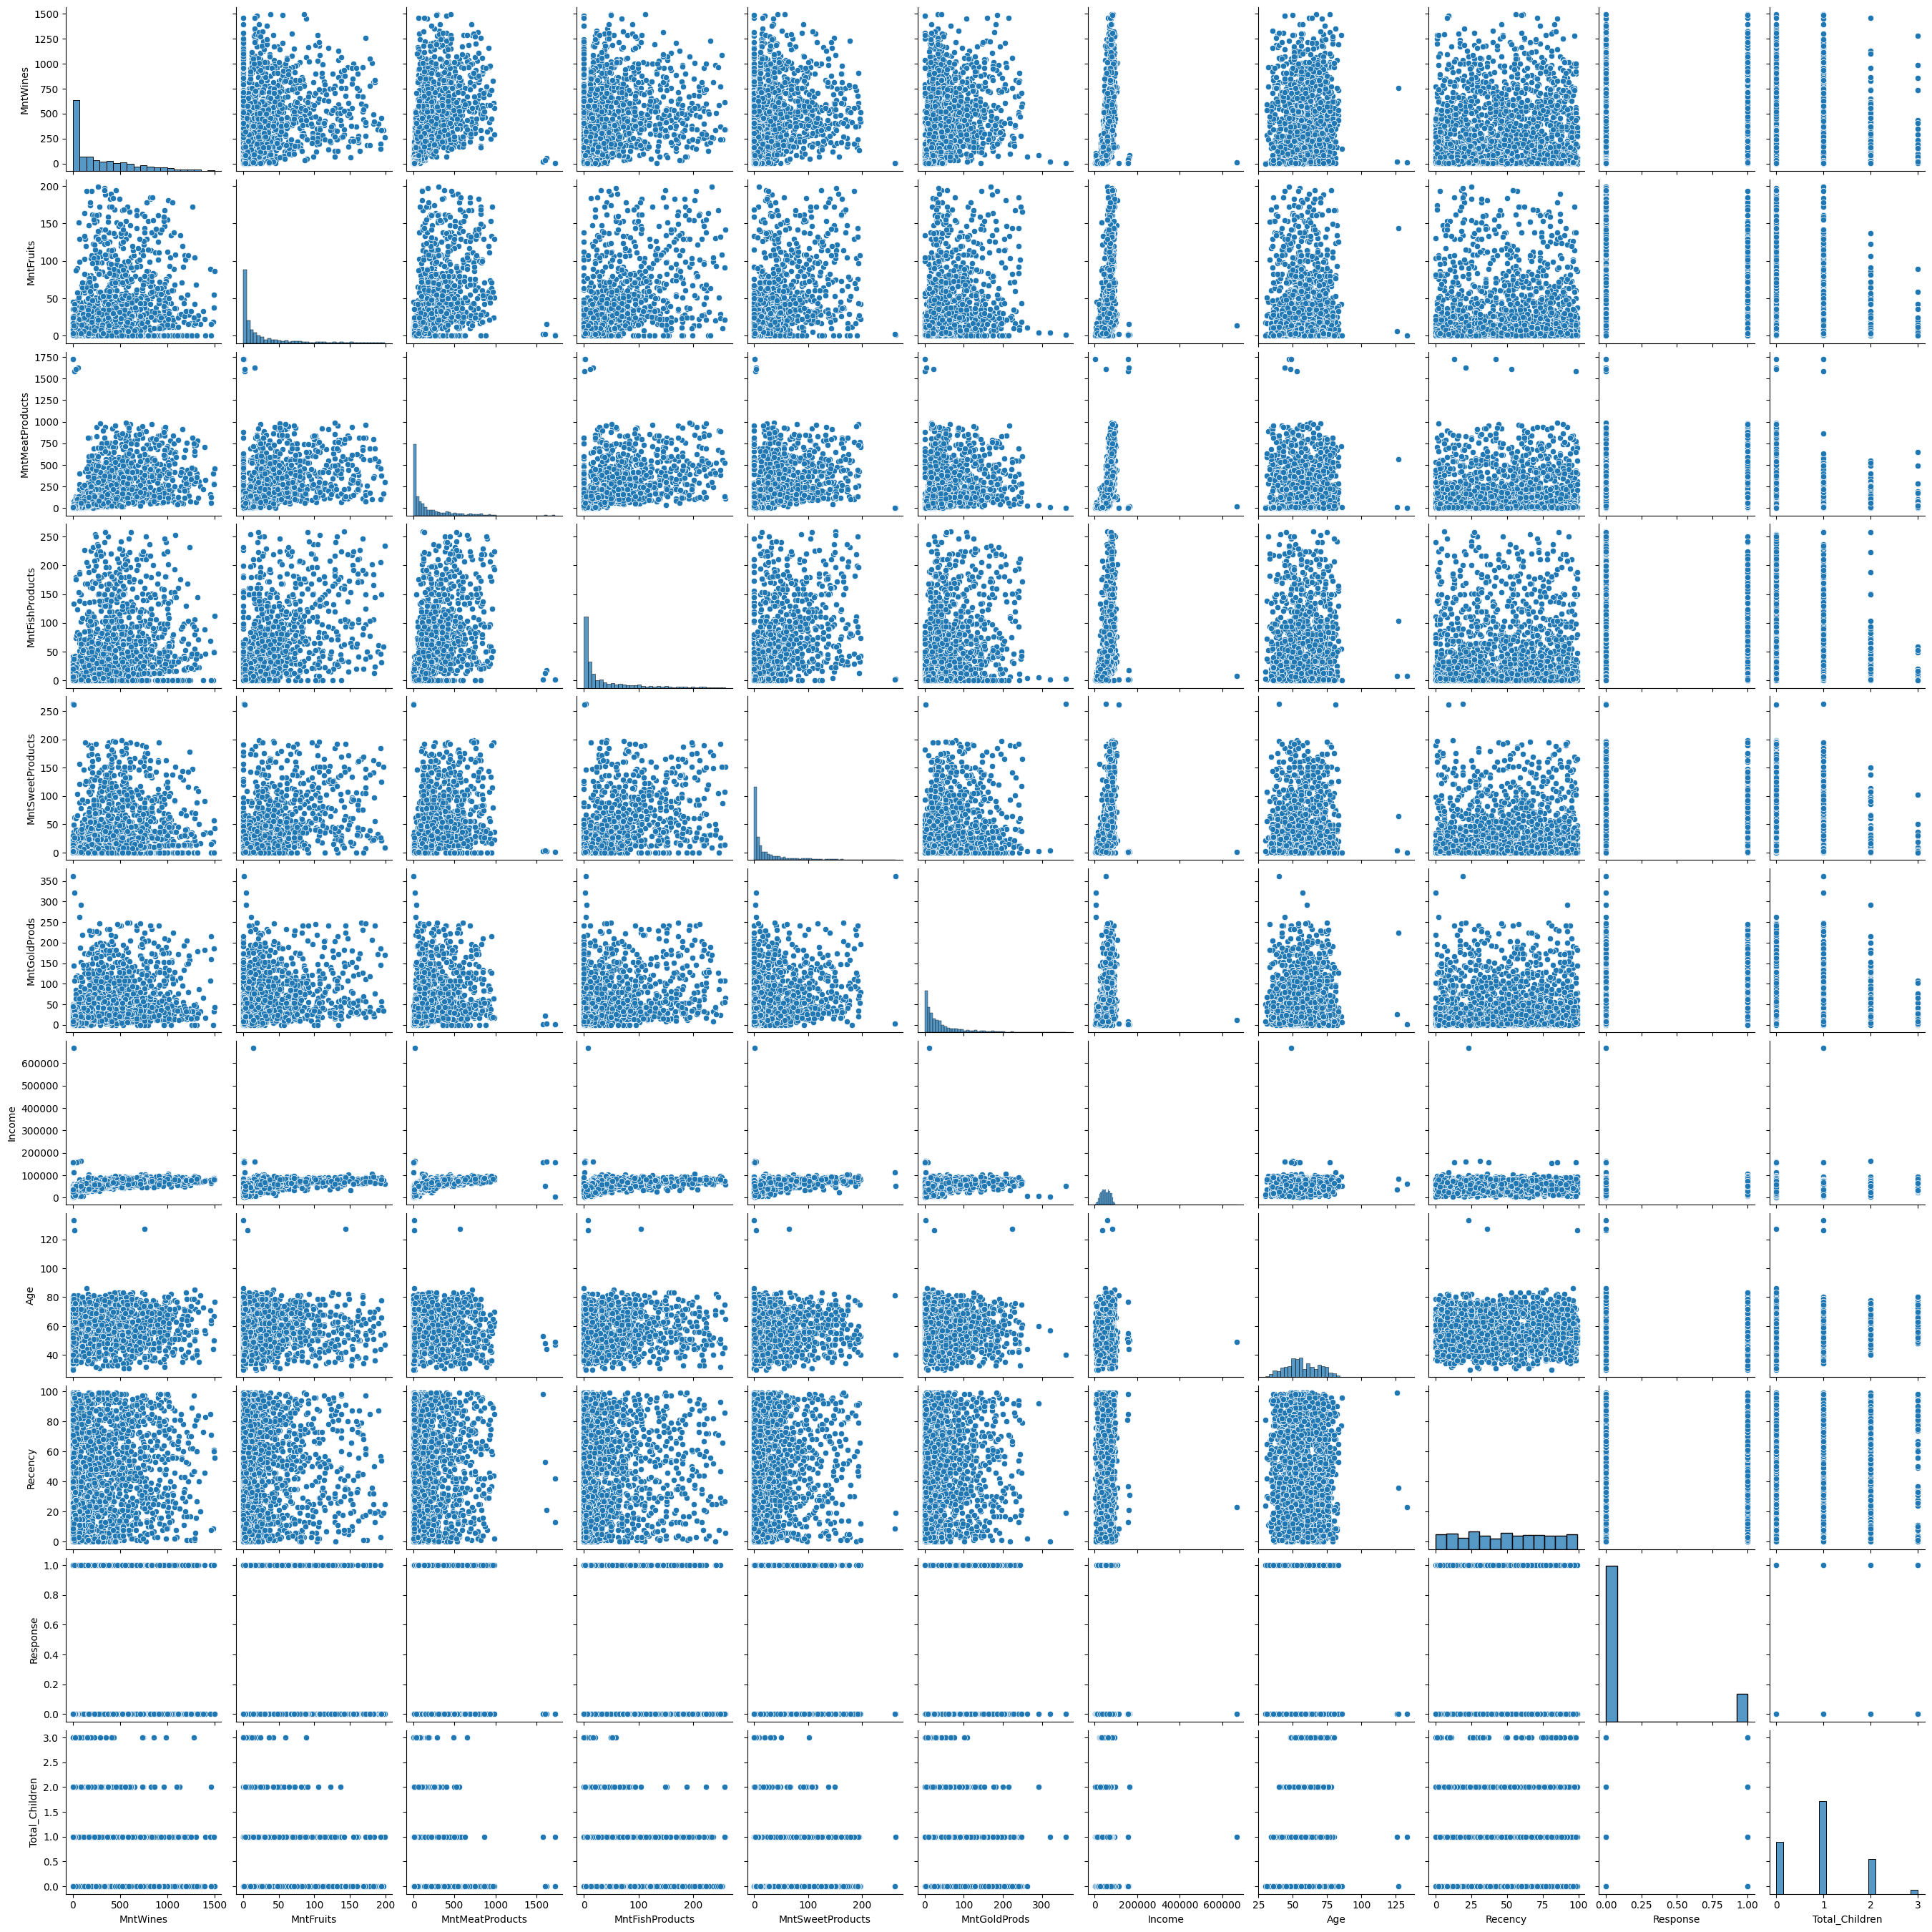

In [144]:
spending_cols = ["MntWines","MntFruits","MntMeatProducts",'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
cols = ["Income","Age","Recency","Response","Total_Children"]
all_cols = spending_cols + cols

sns.pairplot(df[all_cols])

In [149]:
# Inspection identified implausible age values and one extreme income value.

In [150]:
# Remove implausible ages and the extreme income observation

df_no_out = df[df["Age"]<90]
df_no_out = df_no_out[df_no_out["Income"]<600000]

## Correlation Analysis

In [157]:
df_no_out.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tensure_Days',
       'Total_Children', 'Living_With'],
      dtype='object')

In [158]:
spending_cols = ["MntWines","MntFruits","MntMeatProducts",'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

scaler = StandardScaler()
spending_cols_scaled = scaler.fit_transform(df_no_out[spending_cols])

# Convert the scaled array to a DataFrame for labeled analysis
spending_scaled_df = pd.DataFrame(
    spending_cols_scaled,
    columns=spending_cols,
    index=df_no_out.index
)

spending_scaled_df.corr()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
MntWines,1.000000,0.388472,0.561886,0.398956,0.385845,0.386234
MntFruits,0.388472,1.000000,0.542030,0.594415,0.567030,0.389999
MntMeatProducts,0.561886,0.542030,1.000000,0.567813,0.523329,0.348727
MntFishProducts,0.398956,0.594415,0.567813,1.000000,0.579490,0.422018
MntSweetProducts,0.385845,0.567030,0.523329,0.579490,1.000000,0.369084
MntGoldProds,0.386234,0.389999,0.348727,0.422018,0.369084,1.000000


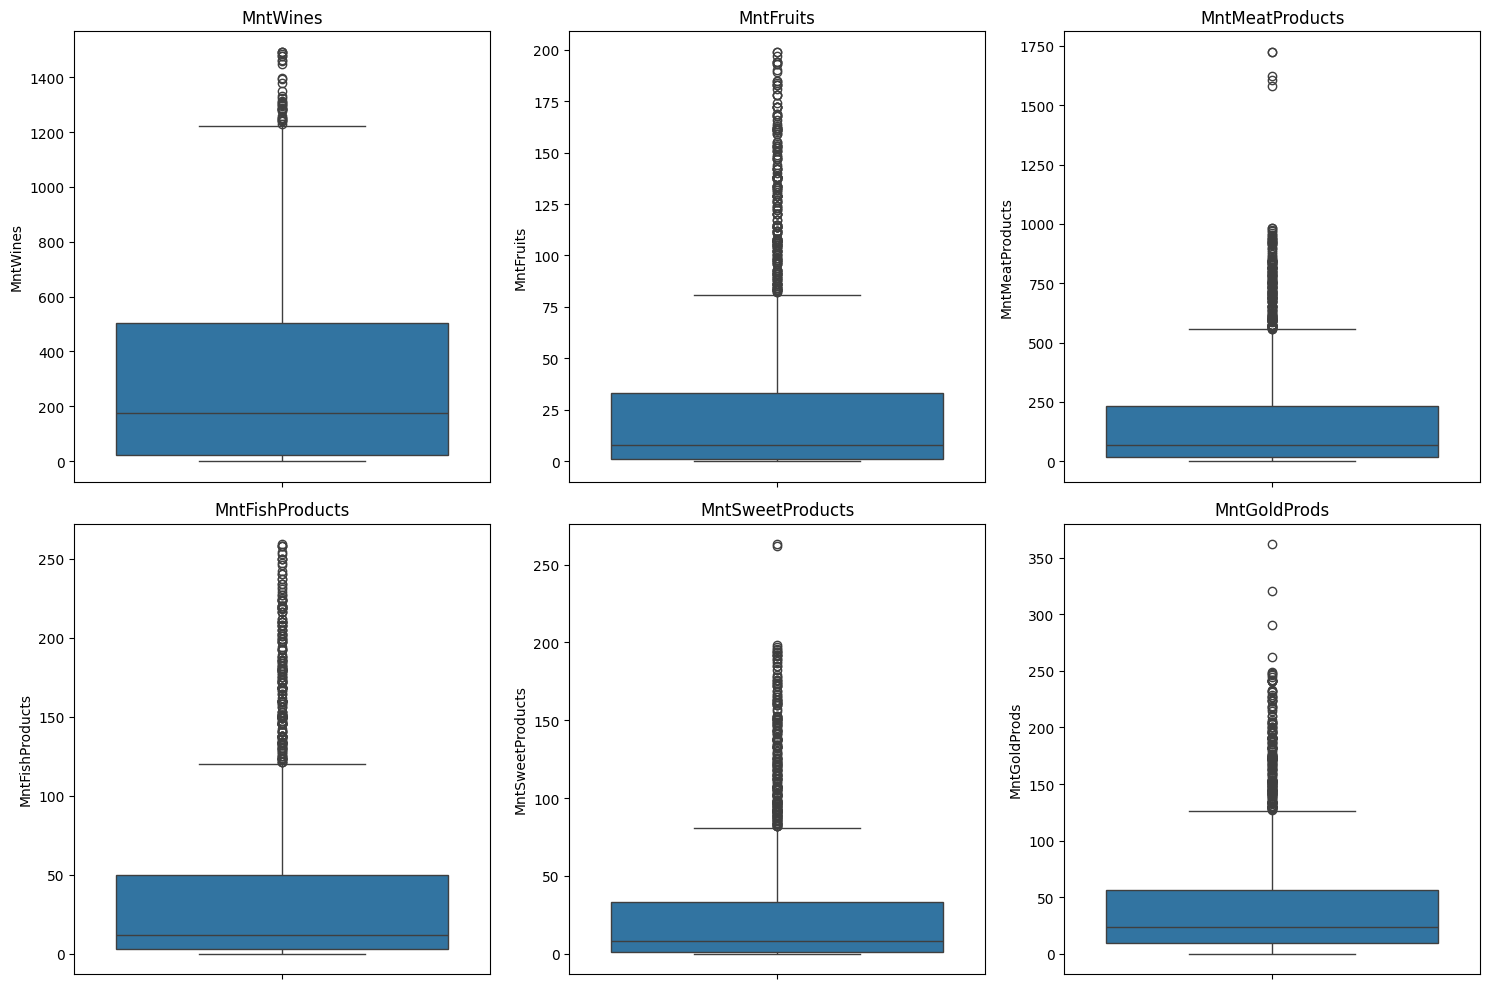

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, col in enumerate(spending_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_no_out[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [160]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pcs = pca.fit_transform(spending_cols_scaled)

df_no_out["spending_pca1"] = pcs[:,0]
df_no_out["spending_pca2"] = pcs[:,1]

pca.explained_variance_ratio_

array([0.56060381, 0.12316064])

In [161]:
df_no_out.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days,Total_Children,Living_With,spending_pca1,spending_pca2
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,1,69,663,0,Alone,3.757570,-0.654598
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,72,113,2,Alone,-1.709468,-0.315934
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,61,312,0,Partner,0.819427,-0.327206
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,42,139,1,Partner,-1.571747,-0.409012
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,45,161,1,Partner,-0.181495,-0.733109


In [162]:
df_no_out.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tensure_Days',
       'Total_Children', 'Living_With', 'spending_pca1', 'spending_pca2'],
      dtype='object')

#### Drop Columns

In [163]:
cols = ["ID","Year_Birth","Dt_Customer","Marital_Status","Kidhome","Teenhome"]
cols_to_drop = cols + spending_cols
df_cleaned = df_no_out.drop(columns=cols_to_drop)

In [164]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days,Total_Children,Living_With,spending_pca1,spending_pca2
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,0,Alone,3.757570,-0.654598
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,2,Alone,-1.709468,-0.315934
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,0,Partner,0.819427,-0.327206
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,1,Partner,-1.571747,-0.409012
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,1,Partner,-0.181495,-0.733109


In [165]:
df.shape

(2240, 28)

In [166]:
df_cleaned.shape

(2236, 16)

In [167]:
df_no_out.shape

(2236, 28)

## Correlation Analysis

In [168]:
corr = df_cleaned.corr(numeric_only=True)

In [169]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days,Total_Children,spending_pca1,spending_pca2
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,-0.340550,7.347955e-01,1.637885e-01
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.017826,1.676156e-02,1.459941e-02
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,0.439682,-1.092860e-01,1.838055e-01
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,-0.146429,4.782662e-01,2.974954e-01
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,-0.439631,7.368277e-01,1.763020e-01
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,-0.321729,6.375159e-01,1.885620e-01
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,0.417908,-5.412826e-01,8.750310e-02
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,0.031480,-2.766541e-02,-2.905960e-02
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,-0.169451,2.156831e-01,1.374001e-01
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.095512,6.886082e-02,1.254191e-01


<Axes: >

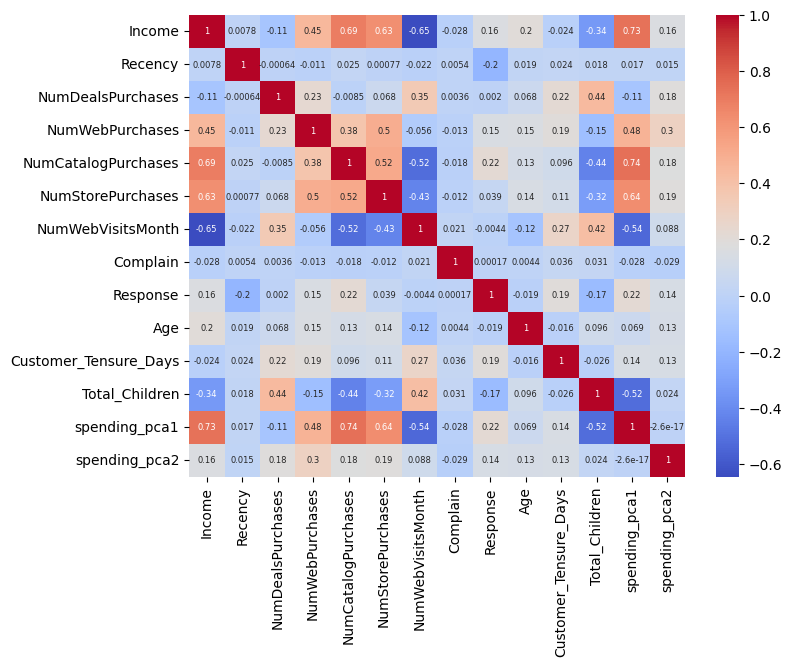

In [173]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

### Key Correlation Observations

- Income shows a strong positive correlation with Spending PC1.
- Higher-income customers tend to make more catalog and store purchases.
- Income is negatively associated with monthly website visits.
- Spending PC1 is strongly associated with catalog and store purchasing activity.

### Feature Encoding

In [175]:
from sklearn.preprocessing import OneHotEncoder

In [176]:
ohe = OneHotEncoder()

In [178]:
cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [182]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [183]:
enc_df.head()

,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [185]:
 df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [187]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days,Total_Children,spending_pca1,spending_pca2,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,0,3.757570,-0.654598,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,2,-1.709468,-0.315934,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,0,0.819427,-0.327206,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,1,-1.571747,-0.409012,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,1,-0.181495,-0.733109,0.0,1.0,0.0,0.0,1.0


### Scaling

In [188]:
X = df_encoded

scaler = StandardScaler()

X_Scaled = scaler.fit_transform(X)

In [192]:
X_Scaled.shape

(2236, 19)

## PCA-Based Data Visualization

In [194]:
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_Scaled)

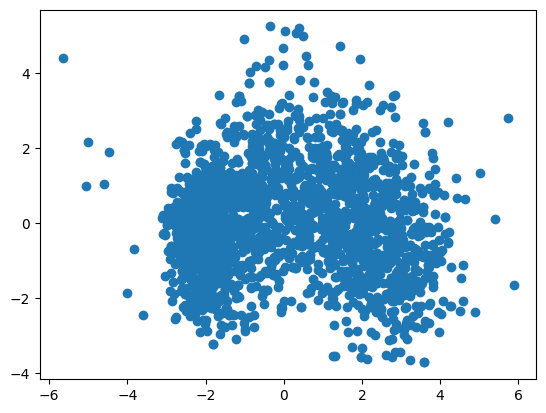

In [197]:
# Plot

plt.scatter(
    X_pca[:,0],
    X_pca[:,1]
)

In [201]:
pca.explained_variance_ratio_

array([0.21797223, 0.10866102])

In [202]:
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_Scaled)

pca.explained_variance_ratio_

array([0.21797223, 0.10866102, 0.10760552])

Text(0.5, 0.92, '3D visualisation')

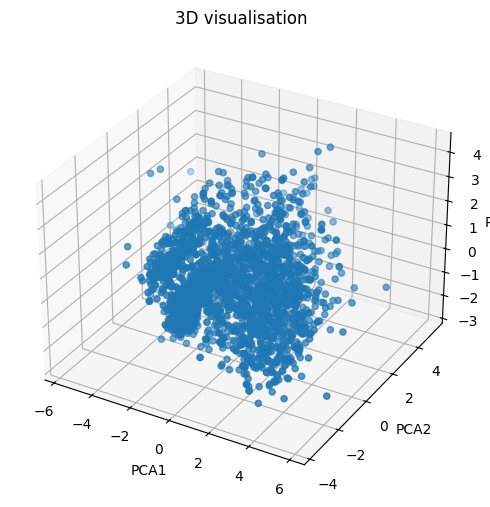

In [207]:
# 3D VISUALISATION

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visualisation")

## Selecting the Number of Clusters
### 1. Elbow Method

In [209]:
from kneed import KneeLocator

wcss=[]

for k in range(1,10):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [210]:
knee = KneeLocator(range(1,10),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [211]:
print("optimal k value : ",optimal_k)

optimal k value :  4


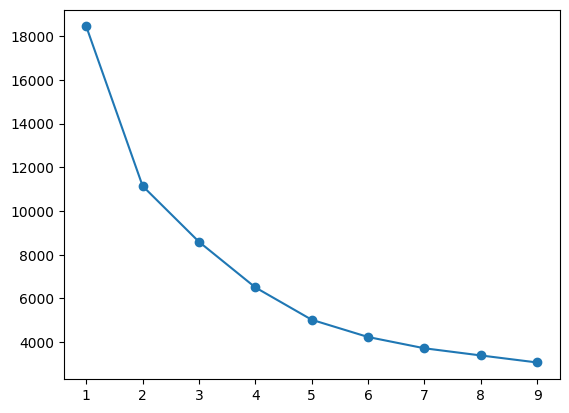

In [212]:
# plot

plt.plot(range(1,10),wcss,marker="o")

### 2. Silhouette Score

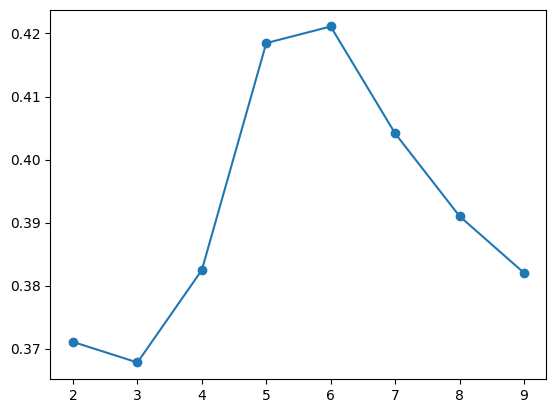

In [213]:
from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,10):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot 
plt.plot(range(2,10),scores,marker="o")

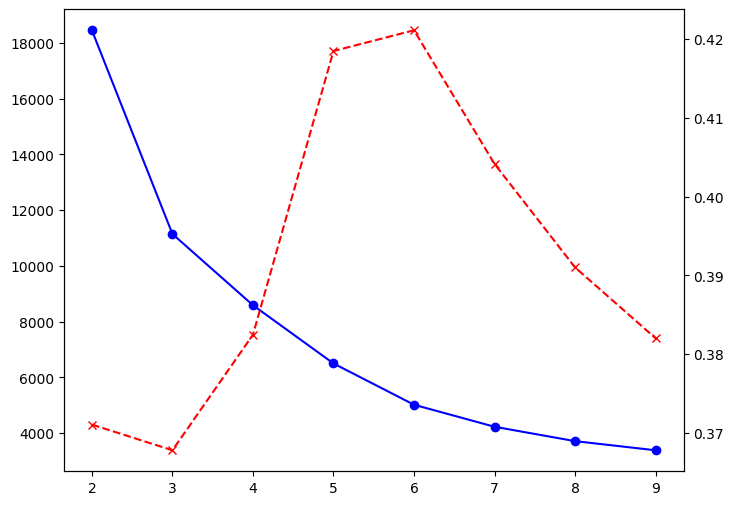

In [217]:
# combined plot

k_range = range(2,10)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")

## Clustering

### K Means

In [218]:
kmeans = KMeans(n_clusters=4,random_state=4)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D visualisation')

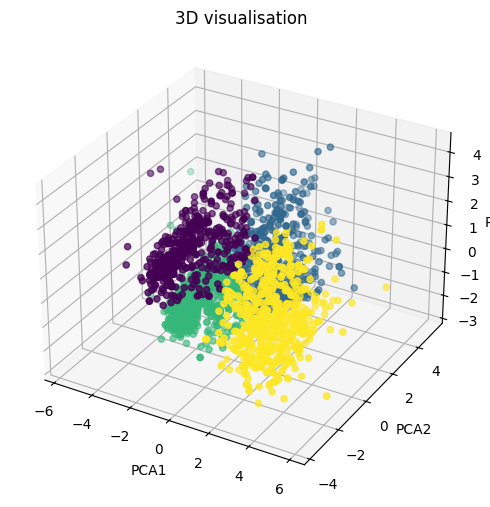

In [219]:
# 3D VISUALISATION

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels_kmeans
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visualisation")

### Agglomerative Clustering

In [220]:
from sklearn.cluster import AgglomerativeClustering

In [221]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")

labels_agg = agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3D visualisation')

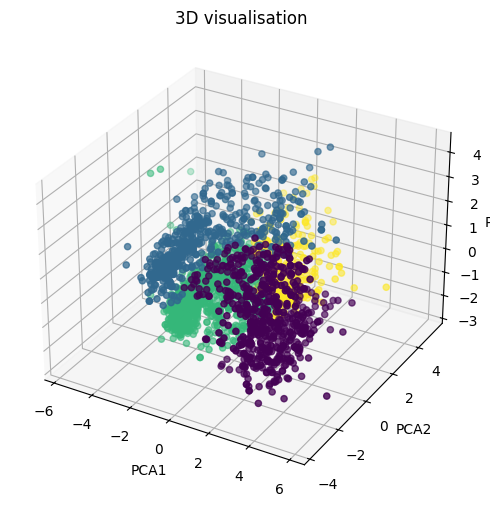

In [222]:
# 3D VISUALISATION

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels_agg
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D visualisation")

## Characterisation of Clusters

In [223]:
df_cleaned["labels"] = labels_agg

In [224]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tensure_Days,Total_Children,Living_With,spending_pca1,spending_pca2,labels
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,0,Alone,3.757570,-0.654598,0
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,2,Alone,-1.709468,-0.315934,1
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,0,Partner,0.819427,-0.327206,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,1,Partner,-1.571747,-0.409012,2
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,1,Partner,-0.181495,-0.733109,2


<Axes: xlabel='labels', ylabel='count'>

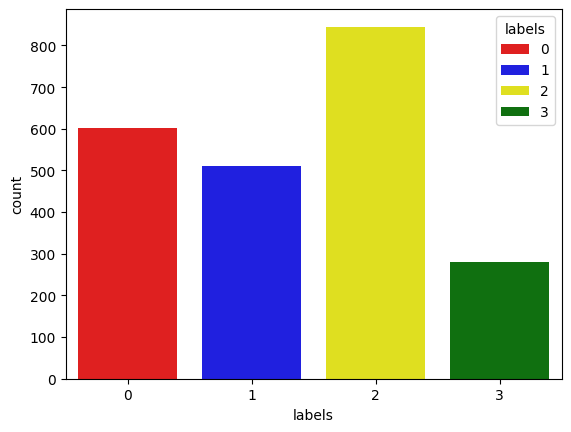

In [229]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=df_cleaned["labels"],hue=df_cleaned["labels"],palette=pal)

<Axes: xlabel='spending_pca1', ylabel='Income'>

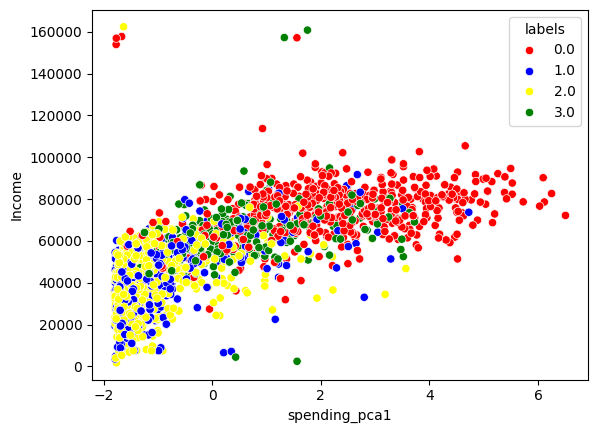

In [228]:
# Income and Spending Patterns

sns.scatterplot(x=df_cleaned["spending_pca1"],y=df["Income"],hue = df_cleaned["labels"],palette=pal)

### Customer Segment Interpretation

- **Cluster 0 — High-Value Customers:** High income and high spending; suitable for loyalty programs and premium offers.
- **Cluster 1 — Price-Sensitive Individual Customers:** Low-to-moderate income, lower spending, and predominantly living alone; suitable for discounts and promotional notifications.
- **Cluster 2 — Budget-Conscious Family Customers:** Lower income and spending, predominantly living with partners; suitable for value bundles and family-oriented promotions.
- **Cluster 3 — Engaged Premium Family Customers:** Moderate-to-high income, strong spending, and frequent purchases; suitable for cross-selling and premium loyalty campaigns.

Clusters 0 and 3 represent premium customer groups, while Clusters 1 and 2 are more price-sensitive.

### Cluster Summary

In [232]:
X["labels"] = labels_agg

cluster_summary = X.groupby("labels").mean()
print(cluster_summary)

              Income    Recency  NumDealsPurchases  NumWebPurchases  \
labels                                                                
0       74244.093854  50.184385           1.313953         5.019934   
1       41464.937255  47.603922           2.643137         3.615686   
2       38440.500000  49.031953           2.315976         2.818935   
3       63948.960573  49.831541           3.960573         6.781362   

        NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
labels                                                                        
0                  5.443522           8.312292           2.845515  0.006645   
1                  1.482353           4.539216           6.452941  0.009804   
2                  0.865089           3.920710           6.311243  0.013018   
3                  4.268817           8.340502           5.577061  0.000000   

        Response        Age  Customer_Tensure_Days  Total_Children  \
labels                      